## BMF walk-off calculation

Brehat and Wyncke (1989, J. Phys. B 22, 1891) の double-refraction walk-off の定義と、Wyncke and Brehat (1989, J. Phys. B 22, 363) の電場ベクトル式を使って、BMF の各 `dij` 測定条件ごとに以下を計算します。

- `omega`, `2omega` の E ベクトル単位ベクトル
- `omega`, `2omega` の絶対ウォークオフ角 `rho`
- `omega` と `2omega` の相対ウォークオフ角

type II (`d15`, `d24`) では fundamental が2つの直交固有偏光を持つので、`omega_1`, `omega_2` を両方表示します。


In [130]:
import copy
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [131]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "test_codes":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [132]:
from crystaldatabase import CRYSTALS
from fitting_strategies.base import BaseRotationStrategy

### Mock metadata

`BMF_coherence_length_vs_wavelength.ipynb` と同じ発想で、BMF の各 `dij` 測定条件を mock `meta` として置きます。ここでは wedge 実験条件を入り口にしつつ、walk-off 計算は対応する Bechthold の rotation-theory frame で評価します。`theta_deg=0` が法線入射、配列を渡すと角度依存も計算できます。


In [133]:
meta_base = {
    "sample": "BMF_mock",
    "material": "BaMgF4",
    "method": "rotation",
    "wavelength_nm": 1064.0,
    "ref_ch": 1,
    "sig_ch": 2,
    "repetition": "1000Hz",
    "operator": "user",
    "notes": "mock metadata for BMF walk-off calculation",
    "thickness_info": {"wedge_angle_deg": 0, "t_center_mm": 1.0},
    "beam_r_x": 359.6,
    "beam_r_y": 423.2,
}

# Wedge measurement configurations used in the local Bechthold1977WedgeStrategy.
wedge_meta_configs = {
    "d31": {"crystal_orientation": "010", "rot/trans_axis": "100", "input_polarization": 90.0, "detected_polarization": 0.0},
    "d32": {"crystal_orientation": "100", "rot/trans_axis": "001", "input_polarization": 0.0, "detected_polarization": 90.0},
    "d33": {"crystal_orientation": "010", "rot/trans_axis": "100", "input_polarization": 0.0, "detected_polarization": 0.0},
    "d15": {"crystal_orientation": "010", "rot/trans_axis": "100", "input_polarization": 45.0, "detected_polarization": 90.0},
    "d24": {"crystal_orientation": "100", "rot/trans_axis": "001", "input_polarization": 45.0, "detected_polarization": 0.0},
}

# The matching rotation-theory configurations used by Bechthold's formulae.
rotation_theory_configs = {
    "d31": {"crystal_orientation": "010", "rot/trans_axis": "100", "input_polarization": 0.0, "detected_polarization": 90.0, "pm_type": "I"},
    "d32": {"crystal_orientation": "100", "rot/trans_axis": "010", "input_polarization": 0.0, "detected_polarization": 90.0, "pm_type": "I"},
    "d33": {"crystal_orientation": "010", "rot/trans_axis": "001", "input_polarization": 0.0, "detected_polarization": 0.0, "pm_type": "I"},
    "d15": {"crystal_orientation": "010", "rot/trans_axis": "100", "input_polarization": 45.0, "detected_polarization": 0.0, "pm_type": "II"},
    "d24": {"crystal_orientation": "100", "rot/trans_axis": "010", "input_polarization": 45.0, "detected_polarization": 0.0, "pm_type": "II"},
}

meta_dict = {}
for dij, config in wedge_meta_configs.items():
    meta = copy.deepcopy(meta_base)
    meta.update(config)
    meta["dij"] = dij
    meta["rotation_theory"] = rotation_theory_configs[dij]
    meta_dict[dij] = meta

pd.DataFrame({dij: meta["rotation_theory"] for dij, meta in meta_dict.items()}).T

,crystal_orientation,rot/trans_axis,input_polarization,detected_polarization,pm_type
d31,010,100,0.0,90.0,I
d32,100,010,0.0,90.0,I
d33,010,001,0.0,0.0,I
d15,010,100,45.0,0.0,II
d24,100,010,45.0,0.0,II


### Walk-off functions

計算の流れは以下です。

座標系は、既存コードと同じく結晶軸 `100,010,001` をそのまま `x,y,z` として扱います。

1. 空気中の入射角 `theta_deg` を `base.py` の `BaseRotationStrategy.n_eff()` に渡して、その偏光の有効屈折率を求める。
2. Snell 条件 `sin(theta_air) = n_eff sin(theta_internal)` から、結晶内の屈折角 `theta_internal` を求める。
3. その内部伝搬方向 `s(theta_internal)` に対して、論文の cos vector 式で `E` と `D` の単位ベクトルを求める。
4. Poynting vector の方向は `t = s - (E.s) E` として求め、`rho = angle(s, t)` を計算する。
5. 相対 walk-off は `angle(t_w, t_2w)` として計算する。


In [134]:
AXIS_VECTOR = {
    "100": np.array([1.0, 0.0, 0.0]),
    "010": np.array([0.0, 1.0, 0.0]),
    "001": np.array([0.0, 0.0, 1.0]),
}
BIAXIAL_POL = {"100": "a", "010": "b", "001": "c"}


def unit(v):
    v = np.asarray(v, dtype=float)
    norm = np.linalg.norm(v)
    if norm == 0:
        raise ValueError("zero vector cannot be normalized")
    return v / norm


def rotate_v_around_axis(v, axis, angle_deg):
    v = np.asarray(v, dtype=float)
    k = unit(axis)
    th = np.deg2rad(angle_deg)
    return v * np.cos(th) + np.cross(k, v) * np.sin(th) + k * np.dot(k, v) * (1.0 - np.cos(th))


def perpendicular_basis(s):
    s = unit(s)
    trial = np.array([1.0, 0.0, 0.0])
    if abs(np.dot(trial, s)) > 0.9:
        trial = np.array([0.0, 1.0, 0.0])
    u = unit(trial - np.dot(trial, s) * s)
    v = unit(np.cross(s, u))
    return np.column_stack([u, v])


def principal_indices(material, wavelength_nm):
    crystal = CRYSTALS[material]()
    return np.array([crystal.get_n(wavelength_nm, polarization=BIAXIAL_POL[axis]) for axis in ("100", "010", "001")], dtype=float)


def calculate_d(s, n_eff, n_principal, fallback=None):
    """Electric-displacement unit cos vector from Brehat and Wyncke Eq. (4)."""
    d, _ = calculate_d_with_diagnostics(s, n_eff, n_principal, fallback=fallback)
    return d


def calculate_d_with_diagnostics(s, n_eff, n_principal, fallback=None):
    """Electric-displacement unit cos vector plus a flag showing whether fallback was used."""
    s = unit(s)
    n_principal = np.asarray(n_principal, dtype=float)
    inv_n2 = 1.0 / (n_principal**2)
    inv_n_eff2 = 1.0 / (n_eff**2)
    denom = inv_n2 - inv_n_eff2
    zero_denom = np.isclose(denom, 0.0, rtol=1e-10, atol=1e-12)
    zero_numer = np.isclose(s, 0.0, rtol=0.0, atol=1e-12)

    limit = zero_denom & zero_numer
    bad = zero_denom & ~zero_numer
    if np.any(bad):
        if fallback is None:
            raise ValueError("calculate_d has a zero denominator with nonzero numerator. Add fallback.")
        return unit(fallback), True

    if np.any(limit):
        # In the D-vector formula, a 0/0 component is the dominant limiting component.
        # Set that component to 1 and all other components to 0.
        d = np.zeros_like(s, dtype=float)
        d[limit] = 1.0
        return unit(d), False

    d = s / denom
    if np.all(np.isfinite(d)) and np.linalg.norm(d) > 1e-12:
        return unit(d), False
    if fallback is None:
        raise ValueError("calculate_d failed. Add fallback.")
    return unit(fallback), True


def calculate_e(s, n_eff, n_principal, fallback=None):
    """Electric-field unit cos vector from E = eta D."""
    e, _ = calculate_e_with_diagnostics(s, n_eff, n_principal, fallback=fallback)
    return e


def calculate_e_with_diagnostics(s, n_eff, n_principal, fallback=None):
    """Electric-field unit cos vector plus a flag showing whether fallback was used."""
    try:
        d, d_used_fallback = calculate_d_with_diagnostics(s, n_eff, n_principal, fallback=None)
    except ValueError:
        if fallback is None:
            raise
        return unit(fallback), True
    e = d / (np.asarray(n_principal, dtype=float) ** 2)
    if np.all(np.isfinite(e)) and np.linalg.norm(e) > 1e-12:
        return unit(e), d_used_fallback
    if fallback is None:
        raise ValueError("calculate_e failed. Add fallback.")
    return unit(fallback), True


def general_eigenmodes(material, wavelength_nm, s):
    """General eigen-solver used for n_eff and as a singular-axis fallback."""
    s = unit(s)
    n_principal = principal_indices(material, wavelength_nm)
    eta = np.diag(1.0 / n_principal**2)

    basis = perpendicular_basis(s)
    projected_eta = basis.T @ eta @ basis
    q_vals, q_vecs = np.linalg.eigh(projected_eta)

    modes = []
    for q, coeff in zip(q_vals, q_vecs.T):
        d_vec = unit(basis @ coeff)
        e_vec = unit(eta @ d_vec)
        # Choose a stable sign for cleaner tables.
        if e_vec[np.argmax(np.abs(e_vec))] < 0:
            e_vec = -e_vec
            d_vec = -d_vec
        e_eigen = e_vec.copy()
        d_eigen = d_vec.copy()
        n_eff = float(1.0 / np.sqrt(q))
        e_paper, e_used_fallback = calculate_e_with_diagnostics(s, n_eff, n_principal, fallback=e_vec)
        d_paper, d_used_fallback = calculate_d_with_diagnostics(s, n_eff, n_principal, fallback=d_vec)
        if e_paper[np.argmax(np.abs(e_paper))] < 0:
            e_paper = -e_paper
            d_paper = -d_paper
        t_vec = unit(s - np.dot(e_paper, s) * e_paper)
        rho_deg = float(np.rad2deg(np.arccos(np.clip(np.dot(s, t_vec), -1.0, 1.0))))
        modes.append({
            "n": n_eff,
            "D": d_paper,
            "E": e_paper,
            "D_eigen": d_eigen,
            "E_eigen": e_eigen,
            "E_used_fallback": e_used_fallback,
            "D_used_fallback": d_used_fallback,
            "t": t_vec,
            "rho_deg": rho_deg,
        })

    # Paper convention: mode 1 has the smaller n, mode 2 has the larger n.
    modes = sorted(modes, key=lambda m: m["n"])
    for i, mode in enumerate(modes, start=1):
        mode["mode"] = i
    return modes


def propagation_direction(config, internal_angle_deg=0.0):
    cut = AXIS_VECTOR[config["crystal_orientation"]]
    rot = AXIS_VECTOR[config["rot/trans_axis"]]
    return unit(rotate_v_around_axis(cut, rot, internal_angle_deg))


rotation_n_eff = BaseRotationStrategy(None)


def theory_meta_for_config(material, config):
    return {
        "material": material,
        "crystal_orientation": config["crystal_orientation"],
        "rot/trans_axis": config["rot/trans_axis"],
        "wavelength_nm": 1064.0,
    }


def n_eff_from_base(material, wavelength_nm, config, incident_angle_deg, pol_deg):
    """Effective index using BaseRotationStrategy.n_eff from base.py with the external incident angle."""
    return float(
        rotation_n_eff.n_eff(
            pol_deg,
            wavelength_nm,
            theta_deg=incident_angle_deg,
            meta=theory_meta_for_config(material, config),
        )
    )


def solve_internal_refraction_angle(material, wavelength_nm, config, incident_angle_deg, pol_deg):
    """Internal propagation angle from Snell's law using base.py n_eff at the external incident angle."""
    if np.isclose(incident_angle_deg, 0.0, atol=1e-12):
        return 0.0

    sign = 1.0 if incident_angle_deg >= 0.0 else -1.0
    sin_theta_air = abs(np.sin(np.deg2rad(incident_angle_deg)))
    n_eff = n_eff_from_base(material, wavelength_nm, config, incident_angle_deg, pol_deg)
    sin_alpha = sin_theta_air / n_eff

    return sign * float(np.rad2deg(np.arcsin(np.clip(sin_alpha, -1.0, 1.0))))


def mode_from_eigen_by_n(modes, n_target, *, rtol=1e-9, atol=1e-10):
    """Map a base.py polarization index to eigenmode 1/2 by matching n_eff, and fail if it does not match."""
    diffs = np.array([abs(mode["n"] - n_target) for mode in modes], dtype=float)
    idx = int(np.argmin(diffs))
    if not np.isclose(modes[idx]["n"], n_target, rtol=rtol, atol=atol):
        candidates = ", ".join(f"mode {mode['mode']}: n={mode['n']:.12g}" for mode in modes)
        raise ValueError(
            f"base.py n_eff={n_target:.12g} does not match any eigenmode within "
            f"rtol={rtol}, atol={atol}. Candidates: {candidates}"
        )
    return modes[idx]


def refracted_mode_for_polarization(material, wavelength_nm, config, incident_angle_deg, pol_deg):
    internal_angle_deg = solve_internal_refraction_angle(
        material, wavelength_nm, config, incident_angle_deg, pol_deg
    )
    s = propagation_direction(config, internal_angle_deg=internal_angle_deg)
    n_base = n_eff_from_base(material, wavelength_nm, config, incident_angle_deg, pol_deg)
    mode = mode_from_eigen_by_n(general_eigenmodes(material, wavelength_nm, s), n_base)
    mode = dict(mode)
    mode["s"] = s
    mode["internal_angle_deg"] = internal_angle_deg
    mode["incident_angle_deg"] = incident_angle_deg
    mode["pol_deg"] = int(round(pol_deg))
    mode["input_pol_vector"] = input_polarization_vectors(config, s)[mode["pol_deg"]]
    mode["n_base"] = n_base
    mode["n_diff_base_minus_eigen"] = n_base - mode["n"]
    mode["n_abs_diff_base_eigen"] = abs(n_base - mode["n"])
    mode["E_used_fallback"] = bool(mode["E_used_fallback"])
    mode["D_used_fallback"] = bool(mode["D_used_fallback"])
    return mode


def input_polarization_vectors(config, s):
    """Lab polarization basis in crystal coordinates: 0 deg is along the rotation axis."""
    rot = AXIS_VECTOR[config["rot/trans_axis"]]
    pol_0 = unit(rot)
    pol_90 = unit(np.cross(pol_0, s))
    return {0: pol_0, 90: pol_90}


def selected_modes_for_condition(meta, theta_deg=0.0):
    config = meta["rotation_theory"]
    material = meta["material"]
    wl_w = float(meta["wavelength_nm"])
    wl_2w = wl_w / 2.0
    sh_mode = refracted_mode_for_polarization(
        material, wl_2w, config, theta_deg, config["detected_polarization"]
    )

    if config["pm_type"] == "II":
        fundamental = [
            refracted_mode_for_polarization(material, wl_w, config, theta_deg, 0),
            refracted_mode_for_polarization(material, wl_w, config, theta_deg, 90),
        ]
    else:
        fundamental = [
            refracted_mode_for_polarization(
                material, wl_w, config, theta_deg, config["input_polarization"]
            )
        ]

    return {"fundamental": fundamental, "second_harmonic": sh_mode}


def angle_between(u, v):
    return float(np.rad2deg(np.arccos(np.clip(np.dot(unit(u), unit(v)), -1.0, 1.0))))


def fmt_vec(v, ndigits=6):
    return tuple(np.round(np.asarray(v, dtype=float), ndigits))

### Consistency check: paper cos vectors vs eigen-solver

`general_eigenmodes()` の固有値法で得た2つの `n` が、`base.py` の `BaseRotationStrategy.n_eff()` と一致するかを確認します。あわせて、固有値法から直接出た `E_eigen`, `D_eigen` と、論文式 `calculate_e()`, `calculate_d()` で出した `E`, `D` が同じ向きになるかも確認します。固有ベクトルは符号が任意なので、角度差は `0 deg` と `180 deg` を同一視した値で表示します。


In [135]:
def unsigned_angle_between(u, v):
    dot = abs(float(np.dot(unit(u), unit(v))))
    return float(np.rad2deg(np.arccos(np.clip(dot, -1.0, 1.0))))


def compare_base_paper_and_eigen(meta_dict, theta_values_deg=(0.0, 10.0, 30.0, 60.0)):
    rows = []
    for dij, meta in meta_dict.items():
        config = meta["rotation_theory"]
        material = meta["material"]
        for incident_angle_deg in theta_values_deg:
            for frequency, wavelength_nm in (
                ("w", float(meta["wavelength_nm"])),
                ("2w", float(meta["wavelength_nm"]) / 2.0),
            ):
                for pol_deg in (0, 90):
                    mode = refracted_mode_for_polarization(material, wavelength_nm, config, incident_angle_deg, pol_deg)
                    rows.append(
                        {
                            "dij": dij,
                            "frequency": frequency,
                            "pol_deg": pol_deg,
                            "mode": mode["mode"],
                            "incident_angle_deg": float(incident_angle_deg),
                            "internal_angle_deg": mode["internal_angle_deg"],
                            "n_base": mode["n_base"],
                            "n_eigen": mode["n"],
                            "n_diff_base_minus_eigen": mode["n_diff_base_minus_eigen"],
                            "n_abs_diff_base_eigen": mode["n_abs_diff_base_eigen"],
                            "E_angle_diff_deg": unsigned_angle_between(mode["E"], mode["E_eigen"]),
                            "D_angle_diff_deg": unsigned_angle_between(mode["D"], mode["D_eigen"]),
                            "E_used_fallback": mode["E_used_fallback"],
                            "D_used_fallback": mode["D_used_fallback"],
                        }
                    )
    return pd.DataFrame(rows)


comparison_df = compare_base_paper_and_eigen(meta_dict)
print(comparison_df.size)
comparison_df.groupby(["frequency", "pol_deg"])[["n_abs_diff_base_eigen", "E_angle_diff_deg", "D_angle_diff_deg", "E_used_fallback", "D_used_fallback"]].max()

1120


n_abs_diff_base_eigen  E_angle_diff_deg  D_angle_diff_deg  \
frequency pol_deg                                                              
2w        0                 0.000000e+00               0.0               0.0   
          90                2.220446e-16               0.0               0.0   
w         0                 0.000000e+00               0.0               0.0   
          90                2.220446e-16               0.0               0.0   

                   E_used_fallback  D_used_fallback  
frequency pol_deg                                    
2w        0                  False            False  
          90                 False            False  
w         0                  False            False  
          90                 False            False

In [136]:
from IPython.display import HTML, display

# Full comparison table. Values close to 0 mean the paper cos-vector formula and eigen-solver agree.
html = comparison_df.to_html(index=False)
html = html.replace(
    '<table border="1" class="dataframe">',
    '<div style="max-height: 520px; overflow: auto; border: 1px solid #ddd;">'
    '<table border="1" class="dataframe" '
    'style="border-collapse: collapse; white-space: nowrap; font-size: 12px;">',
)
html = html.replace('</table>', '</table></div>')
display(HTML(html))


dij,frequency,pol_deg,mode,incident_angle_deg,internal_angle_deg,n_base,n_eigen,n_diff_base_minus_eigen,n_abs_diff_base_eigen,E_angle_diff_deg,D_angle_diff_deg,E_used_fallback,D_used_fallback
d31,w,0,2,0.0,0.000000,1.466772,1.466772,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,w,90,1,0.0,0.000000,1.460024,1.460024,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,2w,0,2,0.0,0.000000,1.474366,1.474366,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,2w,90,1,0.0,0.000000,1.467492,1.467492,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,w,0,2,10.0,6.799076,1.466772,1.466772,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,w,90,1,10.0,6.831791,1.459782,1.459782,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,2w,0,2,10.0,6.763895,1.474366,1.474366,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,2w,90,1,10.0,6.796876,1.467245,1.467245,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,w,0,2,30.0,19.930774,1.466772,1.466772,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,w,90,1,30.0,20.055620,1.458014,1.458014,0.000000e+00,0.000000e+00,0.0,0.0,False,False


In [137]:
# d31だけを詳しく確認する表示。全体表より行数が少ないので、fallbackや特異極限の状態を追いやすいです。
d31_comparison_df = comparison_df[comparison_df["dij"] == "d31"].copy()
html = d31_comparison_df.to_html(index=False)
html = html.replace(
    '<table border="1" class="dataframe">',
    '<div style="max-height: 420px; overflow: auto; border: 1px solid #ddd;">'
    '<table border="1" class="dataframe" '
    'style="border-collapse: collapse; white-space: nowrap; font-size: 12px;">',
)
html = html.replace('</table>', '</table></div>')
display(HTML(html))


dij,frequency,pol_deg,mode,incident_angle_deg,internal_angle_deg,n_base,n_eigen,n_diff_base_minus_eigen,n_abs_diff_base_eigen,E_angle_diff_deg,D_angle_diff_deg,E_used_fallback,D_used_fallback
d31,w,0,2,0.0,0.000000,1.466772,1.466772,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,w,90,1,0.0,0.000000,1.460024,1.460024,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,2w,0,2,0.0,0.000000,1.474366,1.474366,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,2w,90,1,0.0,0.000000,1.467492,1.467492,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,w,0,2,10.0,6.799076,1.466772,1.466772,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,w,90,1,10.0,6.831791,1.459782,1.459782,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,2w,0,2,10.0,6.763895,1.474366,1.474366,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,2w,90,1,10.0,6.796876,1.467245,1.467245,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,w,0,2,30.0,19.930774,1.466772,1.466772,0.000000e+00,0.000000e+00,0.0,0.0,False,False
d31,w,90,1,30.0,20.055620,1.458014,1.458014,0.000000e+00,0.000000e+00,0.0,0.0,False,False


### Summary table at normal incidence


In [138]:
def walkoff_summary(meta_dict, theta_deg=0.0):
    rows = []
    for dij, meta in meta_dict.items():
        selected = selected_modes_for_condition(meta, theta_deg=theta_deg)
        sh = selected["second_harmonic"]
        rel_angles = [angle_between(w["t"], sh["t"]) for w in selected["fundamental"]]

        row = {
            "dij": dij,
            "pm_type": meta["rotation_theory"]["pm_type"],
            "theta_deg": theta_deg,
            "s_2w_crystal_xyz": fmt_vec(sh["s"]),
            "internal_angle_2w_deg": sh["internal_angle_deg"],
            "E_2w_xyz": fmt_vec(sh["E"]),
            "pol_2w_deg": sh["pol_deg"],
            "n_2w_base": sh["n_base"],
            "n_2w_eigen": sh["n"],
            "n_2w_diff": sh["n_diff_base_minus_eigen"],
            "n_2w_abs_diff": sh["n_abs_diff_base_eigen"],
            "E_2w_used_fallback": sh["E_used_fallback"],
            "D_2w_used_fallback": sh["D_used_fallback"],
            "rho_2w_deg": sh["rho_deg"],
            "mode_2w": sh["mode"],
            "relative_walkoff_max_deg": float(np.max(rel_angles)),
        }

        for i, w_mode in enumerate(selected["fundamental"], start=1):
            suffix = "" if len(selected["fundamental"]) == 1 else f"_{i}"
            row[f"E_w{suffix}_xyz"] = fmt_vec(w_mode["E"])
            row[f"s_w{suffix}_crystal_xyz"] = fmt_vec(w_mode["s"])
            row[f"internal_angle_w{suffix}_deg"] = w_mode["internal_angle_deg"]
            row[f"pol_w{suffix}_deg"] = w_mode["pol_deg"]
            row[f"n_w{suffix}_base"] = w_mode["n_base"]
            row[f"n_w{suffix}_eigen"] = w_mode["n"]
            row[f"n_w{suffix}_diff"] = w_mode["n_diff_base_minus_eigen"]
            row[f"n_w{suffix}_abs_diff"] = w_mode["n_abs_diff_base_eigen"]
            row[f"E_w{suffix}_used_fallback"] = w_mode["E_used_fallback"]
            row[f"D_w{suffix}_used_fallback"] = w_mode["D_used_fallback"]
            row[f"rho_w{suffix}_deg"] = w_mode["rho_deg"]
            row[f"mode_w{suffix}"] = w_mode["mode"]
            row[f"relative_walkoff_w{suffix}_2w_deg"] = rel_angles[i - 1]
        rows.append(row)
    return pd.DataFrame(rows).set_index("dij")


summary_0deg = walkoff_summary(meta_dict, theta_deg=0.0)
summary_0deg

,pm_type,theta_deg,s_2w_crystal_xyz,internal_angle_2w_deg,E_2w_xyz,pol_2w_deg,n_2w_base,n_2w_eigen,n_2w_diff,n_2w_abs_diff,...,pol_w_2_deg,n_w_2_base,n_w_2_eigen,n_w_2_diff,n_w_2_abs_diff,E_w_2_used_fallback,D_w_2_used_fallback,rho_w_2_deg,mode_w_2,relative_walkoff_w_2_2w_deg
dij,,,,,,,,,,,,,,,,,,,,,
d31,I,0.0,"(0.0, 1.0, 0.0)",0.0,"(0.0, 0.0, 1.0)",90,1.467492,1.467492,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
d32,I,0.0,"(1.0, 0.0, 0.0)",0.0,"(0.0, 0.0, 1.0)",90,1.467492,1.467492,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
d33,I,0.0,"(0.0, 1.0, 0.0)",0.0,"(0.0, 0.0, 1.0)",0,1.467492,1.467492,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
d15,II,0.0,"(0.0, 1.0, 0.0)",0.0,"(1.0, 0.0, 0.0)",0,1.474366,1.474366,0.0,0.0,...,90.0,1.460024,1.460024,0.0,0.0,False,False,0.0,1.0,0.0
d24,II,0.0,"(1.0, 0.0, 0.0)",0.0,"(0.0, 1.0, 0.0)",0,1.450138,1.450138,0.0,0.0,...,90.0,1.460024,1.460024,0.0,0.0,False,False,0.0,2.0,0.0


### Angle scan

Maker rotation の角度依存を見たい場合は、ここで `theta_values_deg` を変更します。wedge の法線入射だけを見るなら上の `summary_0deg` が対応します。


In [139]:
theta_values_deg = np.linspace(-60.0, 60.0, 241)

scan_rows = []
for theta in theta_values_deg:
    table = walkoff_summary(meta_dict, theta_deg=float(theta)).reset_index()
    scan_rows.append(table)

scan_df = pd.concat(scan_rows, ignore_index=True)
scan_df.head()

,dij,pm_type,theta_deg,s_2w_crystal_xyz,internal_angle_2w_deg,E_2w_xyz,pol_2w_deg,n_2w_base,n_2w_eigen,n_2w_diff,...,pol_w_2_deg,n_w_2_base,n_w_2_eigen,n_w_2_diff,n_w_2_abs_diff,E_w_2_used_fallback,D_w_2_used_fallback,rho_w_2_deg,mode_w_2,relative_walkoff_w_2_2w_deg
0,d31,I,-60.0,"(0.0, 0.805475, -0.59263)",-36.343837,"(-0.0, 0.601771, 0.798669)",90,1.461327,1.461327,-2.220446e-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,d32,I,-60.0,"(0.807997, 0.0, 0.589186)",-36.099270,"(-0.58559, 0.0, 0.810607)",90,1.469867,1.469867,-2.220446e-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,d33,I,-60.0,"(0.59014, 0.807301, 0.0)",-36.166920,"(0.0, 0.0, 1.0)",0,1.467492,1.467492,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,d15,II,-60.0,"(0.0, 0.809305, -0.587388)",-35.971901,"(1.0, 0.0, 0.0)",0,1.474366,1.474366,0.000000e+00,...,90.0,1.453987,1.453987,2.220446e-16,2.220446e-16,False,False,0.637657,1.0,1.222689
4,d24,II,-60.0,"(0.802091, 0.0, 0.597202)",-36.669767,"(0.0, 1.0, 0.0)",0,1.450138,1.450138,0.000000e+00,...,90.0,1.462380,1.462380,-2.220446e-16,2.220446e-16,False,False,0.251820,2.0,0.608107


In [140]:
# Example: maximum relative walk-off in this angle window for each dij.
scan_df.groupby("dij")["relative_walkoff_max_deg"].agg(["min", "max"])

,min,max
dij,,
d15,0.0,1.222689
d24,0.0,0.608107
d31,0.0,0.809329
d32,0.0,1.030527
d33,0.0,0.214542


### Plot walk-off vs incident angle

`theta_deg` に対する absolute walk-off angle と relative walk-off angle を `dij` ごとに描画します。type II の `d15`, `d24` は `omega_1`, `omega_2` の2本を両方表示します。


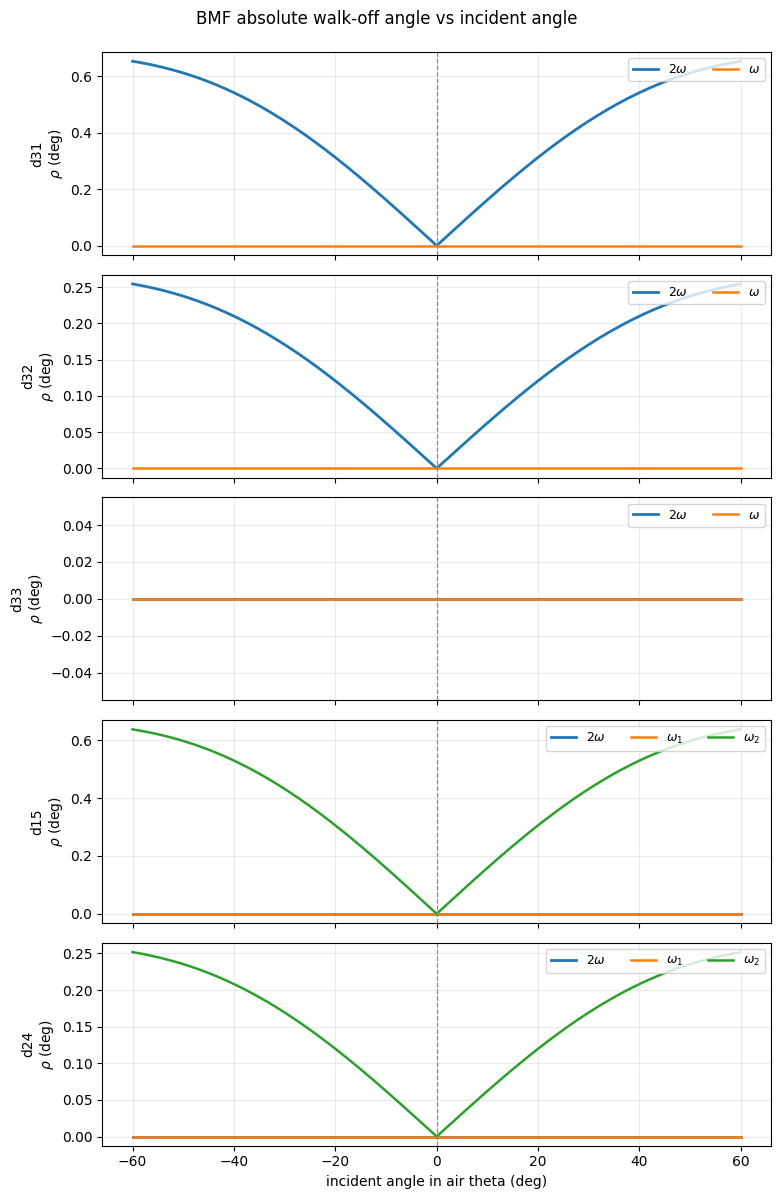

In [141]:
def plot_absolute_walkoff(scan_df):
    dij_order = list(meta_dict.keys())
    fig, axes = plt.subplots(len(dij_order), 1, figsize=(8, 12), sharex=True)

    for ax, dij in zip(axes, dij_order):
        sub = scan_df[scan_df["dij"] == dij].sort_values("theta_deg")
        ax.plot(sub["theta_deg"], sub["rho_2w_deg"], label=r"$2\omega$", linewidth=2.0)

        if sub["pm_type"].iloc[0] == "II":
            ax.plot(sub["theta_deg"], sub["rho_w_1_deg"], label=r"$\omega_1$", linewidth=1.8)
            ax.plot(sub["theta_deg"], sub["rho_w_2_deg"], label=r"$\omega_2$", linewidth=1.8)
        else:
            ax.plot(sub["theta_deg"], sub["rho_w_deg"], label=r"$\omega$", linewidth=1.8)

        ax.axvline(0.0, color="0.55", linestyle="--", linewidth=0.9)
        ax.set_ylabel(f"{dij}\n$\\rho$ (deg)")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="upper right", ncols=3, fontsize=9)

    axes[-1].set_xlabel("incident angle in air theta (deg)")
    fig.suptitle("BMF absolute walk-off angle vs incident angle", y=0.995)
    fig.tight_layout()
    return fig, axes


plot_absolute_walkoff(scan_df)
plt.show()

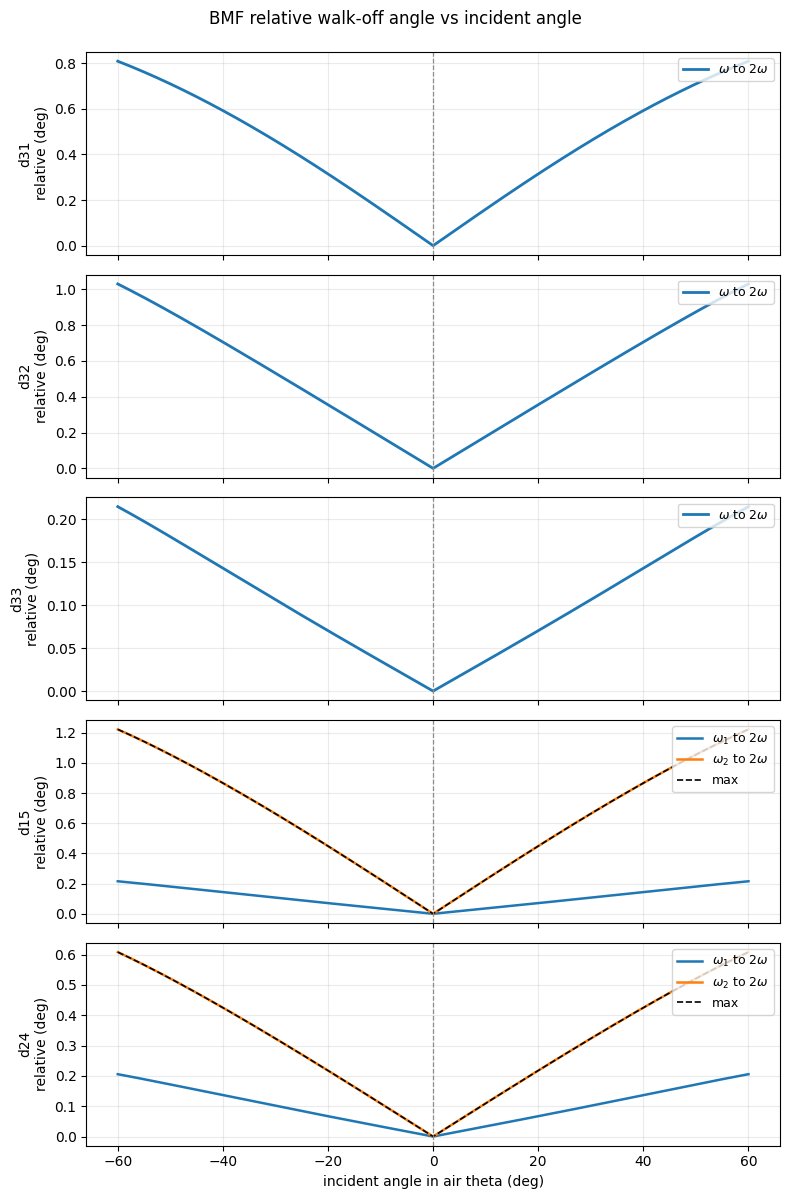

In [142]:
def plot_relative_walkoff(scan_df):
    dij_order = list(meta_dict.keys())
    fig, axes = plt.subplots(len(dij_order), 1, figsize=(8, 12), sharex=True)

    for ax, dij in zip(axes, dij_order):
        sub = scan_df[scan_df["dij"] == dij].sort_values("theta_deg")

        if sub["pm_type"].iloc[0] == "II":
            ax.plot(sub["theta_deg"], sub["relative_walkoff_w_1_2w_deg"], label=r"$\omega_1$ to $2\omega$", linewidth=1.8)
            ax.plot(sub["theta_deg"], sub["relative_walkoff_w_2_2w_deg"], label=r"$\omega_2$ to $2\omega$", linewidth=1.8)
            ax.plot(sub["theta_deg"], sub["relative_walkoff_max_deg"], label="max", color="black", linestyle="--", linewidth=1.2)
        else:
            ax.plot(sub["theta_deg"], sub["relative_walkoff_w_2w_deg"], label=r"$\omega$ to $2\omega$", linewidth=2.0)

        ax.axvline(0.0, color="0.55", linestyle="--", linewidth=0.9)
        ax.set_ylabel(f"{dij}\nrelative (deg)")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="upper right", fontsize=9)

    axes[-1].set_xlabel("incident angle in air theta (deg)")
    fig.suptitle("BMF relative walk-off angle vs incident angle", y=0.995)
    fig.tight_layout()
    return fig, axes


plot_relative_walkoff(scan_df)
plt.show()